# Customer Churn Analytics

> *Pipeline complet de Data Cleaning, EDA, Modélisation & Insights*

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Configuration du style des graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Chargement et exploration initiale

In [7]:
from pathlib import Path

DATA_PATH = Path("../data/Telco-Customer-Churn.csv")

df = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1"
)

print("Dimensions du dataset :", df.shape)

print("\nAperçu des données :")
df.head()

Dimensions du dataset : (7043, 21)

Aperçu des données :


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print("\n Informations générales :")
print(df.info())


 Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBillin

La colonne `TotalCharges` est de type `object` (texte) alors qu'elle devrait être numérique. Elle contient probablement des espaces vides.

In [9]:
print("\nStatistiques descriptives :")
display(df.describe(include='all'))


Statistiques descriptives :


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [10]:
# Vérification des valeurs manquantes
print("\n Valeurs manquantes par colonne :")
print(df.isnull().sum())


 Valeurs manquantes par colonne :
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 3. Data Cleaning

In [11]:
# 1. Nettoyage de TotalCharges : conversion en numérique, remplacement des espaces par NaN, puis fill avec la médiane
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Valeurs NaN dans TotalCharges après conversion : {df['TotalCharges'].isnull().sum()}")

Valeurs NaN dans TotalCharges après conversion : 11


In [12]:
# Imputation par la médiane (car distribution asymétrique)
median_charges = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_charges, inplace=True)

In [13]:
# 2. Suppression des doublons (si existants)
initial_shape = df.shape
df.drop_duplicates(inplace=True)
print(f"Doublons supprimés : {initial_shape[0] - df.shape[0]} lignes")

Doublons supprimés : 0 lignes


In [14]:
# 3. Vérification des valeurs aberrantes pour les colonnes numériques
# (Tenure est bornée entre 0 et 72, MonthlyCharges entre ~18 et 120 -> OK)
print("\nVérification des bornes des colonnes clés :")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())


Vérification des bornes des colonnes clés :
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2281.916928
std      24.559481       30.090047   2265.270398
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    402.225000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


In [15]:
# 4. La colonne 'customerID' n'est pas utile pour la prédiction, on la supprime
df.drop('customerID', axis=1, inplace=True)

print("\n Nettoyage terminé. Shape du dataset :", df.shape)


 Nettoyage terminé. Shape du dataset : (7043, 20)


## 4. Analyse Exploratoire (EDA) et Insights Visuels

### 4.1. Distribution du Churn

 Taux de Churn global : 26.54%


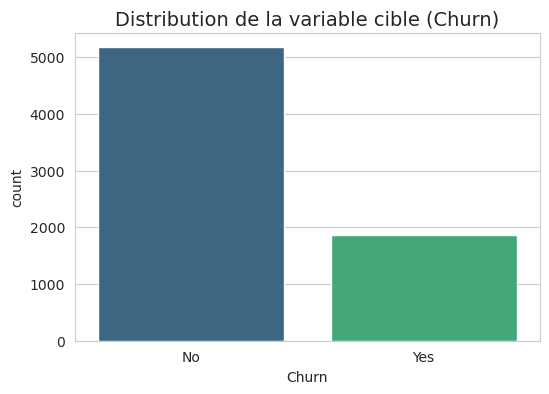

In [16]:
# Taux de Churn global
churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f" Taux de Churn global : {churn_rate:.2f}%")

# Visualisation
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribution de la variable cible (Churn)', fontsize=14)
plt.show()

### 4.2. Churn par Type de Contrat (Insight majeur)

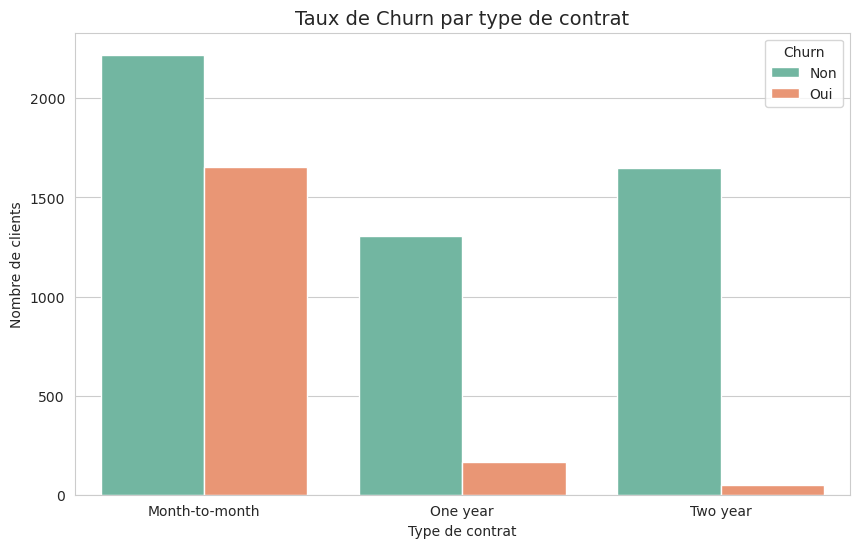

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Taux de Churn par type de contrat', fontsize=14)
plt.xlabel('Type de contrat')
plt.ylabel('Nombre de clients')
plt.legend(title='Churn', labels=['Non', 'Oui'])
plt.show()

In [19]:
# Calcul du taux par contrat
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(" Taux de Churn (%) par type de contrat :")
display(contract_churn)

 Taux de Churn (%) par type de contrat :


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### 4.3. Churn par Ancienneté (Tenure)

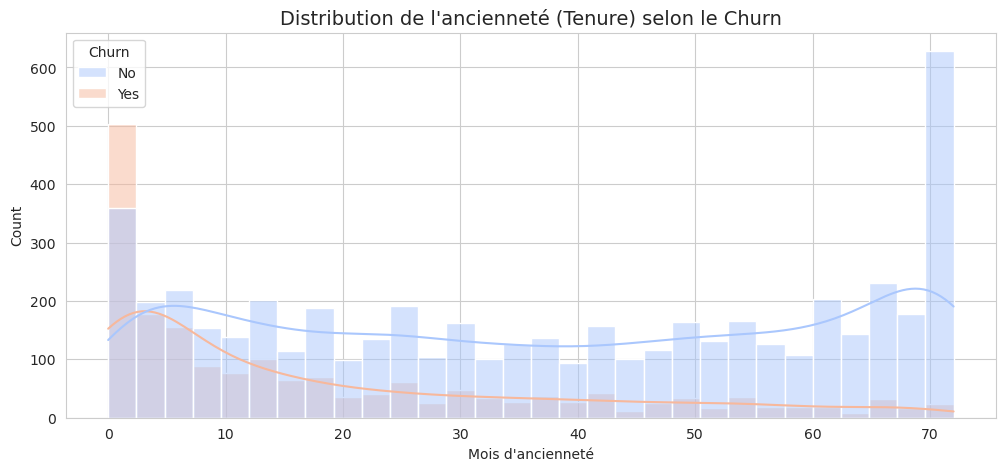

In [20]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, palette='coolwarm')
plt.title('Distribution de l\'ancienneté (Tenure) selon le Churn', fontsize=14)
plt.xlabel('Mois d\'ancienneté')
plt.show()

Les clients partent massivement au cours des **12 premiers mois**. La courbe des clients "Non Churn" grimpe fortement après 1 an. La fidélisation est cruciale en début de cycle.

### 4.3. Churn par Montant Mensuel

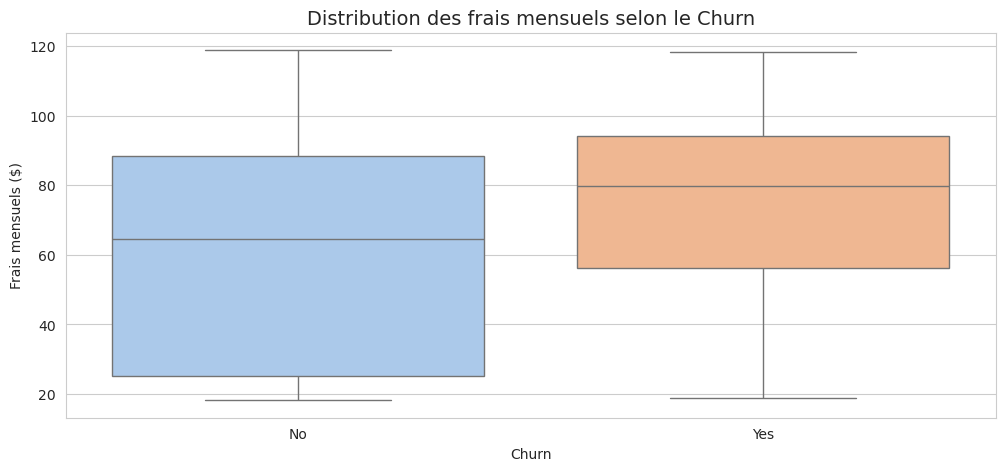

In [21]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='pastel')
plt.title('Distribution des frais mensuels selon le Churn', fontsize=14)
plt.ylabel('Frais mensuels ($)')
plt.show()

La médiane des clients qui partent est plus élevée (~80$) que celle des clients qui restent (~65$). Les clients avec des offres premium ont une exigence plus forte et partent plus facilement si le service n'est pas parfait.

## 5. Feature Engineering & Préprocessing

In [22]:
# Copie du dataset pour le preprocessing
df_encoded = df.copy()

# 1. Transformation de la cible (Churn) en binaire (Yes=1, No=0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

In [23]:
# 2. Encodage des variables catégorielles (One-Hot Encoding)
# On exclut les colonnes déjà numériques (tenure, MonthlyCharges, TotalCharges, Churn)
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
print("Variables catégorielles à encoder :", categorical_cols)

Variables catégorielles à encoder : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [24]:
# Application du One-Hot Encoding (drop_first pour éviter la multicolinéarité)
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print(f"\n Shape après encodage : {df_encoded.shape}")
display(df_encoded.head())


 Shape après encodage : (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 6. Split des données (Train / Test)

In [25]:
# Séparation des features (X) et de la target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [26]:
# Division en entraînement (80%) et test (20%) avec stratification (pour garder le même ratio de Churn)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
print(f" Taille du jeu d'entraînement : {X_train.shape}")
print(f" Taille du jeu de test : {X_test.shape}")
print(f" Répartition du Churn dans le train : {y_train.mean()*100:.2f}%")
print(f" Répartition du Churn dans le test : {y_test.mean()*100:.2f}%")

 Taille du jeu d'entraînement : (5634, 30)
 Taille du jeu de test : (1409, 30)
 Répartition du Churn dans le train : 26.54%
 Répartition du Churn dans le test : 26.54%


## 7. Modélisation & Machine Learning

### 7.1. Baseline : Régression Logistique

In [28]:
# Création et entraînement
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Prédictions
y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

In [29]:
# Évaluation
print(" **RÉGRESSION LOGISTIQUE**")
print(f"Accuracy : {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_log):.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred_log))

 **RÉGRESSION LOGISTIQUE**
Accuracy : 0.8048
ROC-AUC : 0.8425

Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### 7.2. Modèle avancé : Random Forest (avec tuning)

In [30]:
# Modèle de base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [31]:
print(" **RANDOM FOREST (Baseline)**")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_rf):.4f}")

 **RANDOM FOREST (Baseline)**
Accuracy : 0.7864
ROC-AUC : 0.8251


In [32]:
# Optimisation des hyperparamètres (GridSearch)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

print("\n Meilleurs paramètres trouvés :", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits

 Meilleurs paramètres trouvés : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


In [33]:
# Évaluation finale du modèle optimisé
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print("\n **RANDOM FOREST OPTIMISÉ**")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_best):.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred_best))


 **RANDOM FOREST OPTIMISÉ**
Accuracy : 0.8070
ROC-AUC : 0.8434

Classification Report :
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



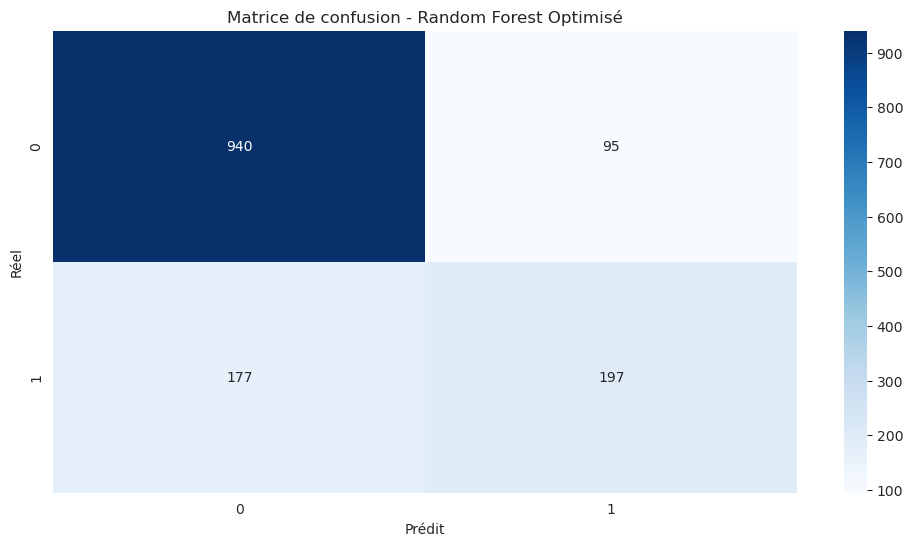

In [34]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Random Forest Optimisé')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

## 8. Feature Importance & Interprétabilité

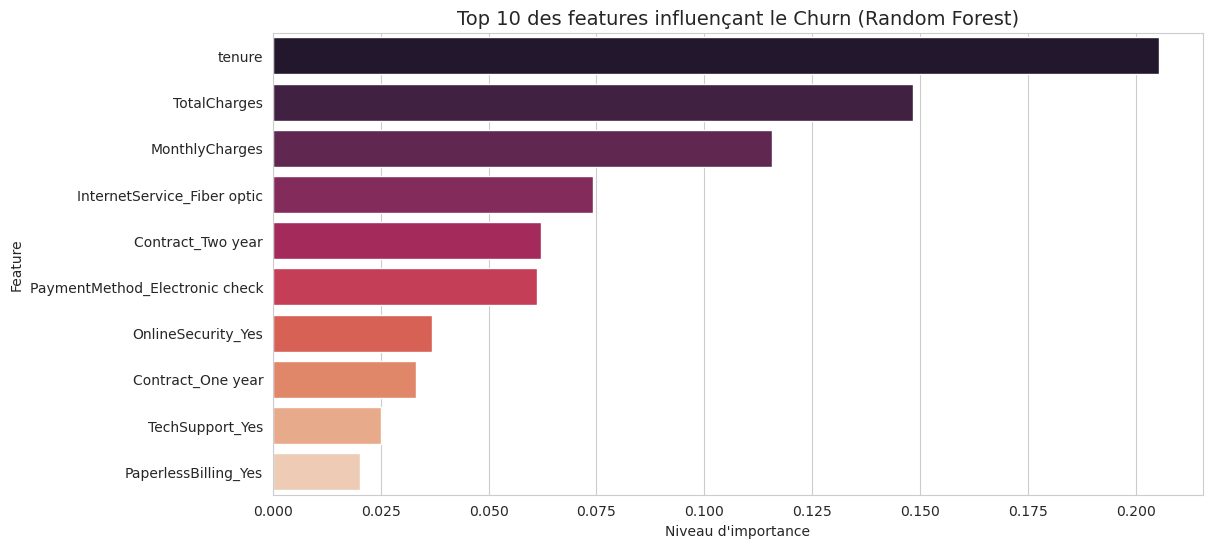

In [36]:
# Extraction de l'importance des features
importances = best_rf.feature_importances_
feature_names = X.columns

# Création d'un DataFrame pour le classement
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='rocket')
plt.title('Top 10 des features influençant le Churn (Random Forest)', fontsize=14)
plt.xlabel('Niveau d\'importance')
plt.show()

In [37]:
display(feature_importance_df)

,Feature,Importance
1,tenure,0.205301
3,TotalCharges,0.148386
2,MonthlyCharges,0.115772
10,InternetService_Fiber optic,0.074278
25,Contract_Two year,0.062112
28,PaymentMethod_Electronic check,0.061174
13,OnlineSecurity_Yes,0.036914
24,Contract_One year,0.033258
19,TechSupport_Yes,0.024962
26,PaperlessBilling_Yes,0.020280


**Détection des facteurs clés** :

1. **Tenure** (ancienneté) : Le plus important.
2. **Contract_Month-to-month** : Le type de contrat.
3. **TotalCharges** (souvent corrélé à l'ancienneté).
4. **InternetService_Fiber optic** : La fibre optique churn plus que le DSL.
5. **PaymentMethod_Electronic check** : Le mode de paiement à risque.

## 9. Courbe ROC et Seuil de Décision

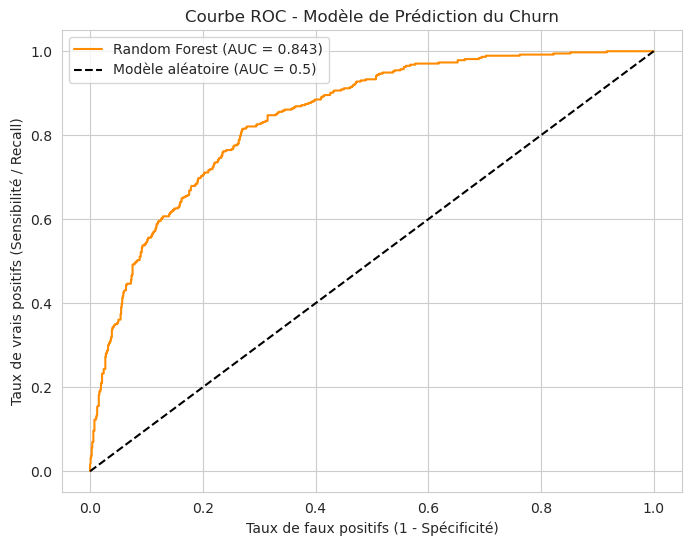

In [38]:
# Courbe ROC du meilleur modèle
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_best):.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire (AUC = 0.5)')
plt.xlabel('Taux de faux positifs (1 - Spécificité)')
plt.ylabel('Taux de vrais positifs (Sensibilité / Recall)')
plt.title('Courbe ROC - Modèle de Prédiction du Churn')
plt.legend()
plt.grid(True)
plt.show()

## 10. Synthèse des Insights Business

En tant qu'expert, voici ce que je retiens de cette analyse et ce que je recommande à l'entreprise :

| Insight Statistique | Traduction Business | Recommandation Actionnable |
| :--- | :--- | :--- |
| **Les contrats mensuels (Month-to-month)** représentent >80% du churn. | Les clients n'ont pas de raison de rester s'ils ne sont pas engagés. | **Lancer une campagne de migration** : offrir 1 mois gratuit ou un upgrade de service pour les clients qui passent sur un contrat d'1 an. |
| **Les 12 premiers mois sont critiques** (Tenure < 12). | La courbe d'apprentissage et les premiers mois d'utilisation sont décisifs. | **Mettre en place un "Onboarding boosté"** : check-up à 3 mois, réduction sur les options additionnelles la première année. |
| **Les clients Fibre (Fiber optic) churnent plus** que ceux en ADSL. | La Fibre est plus chère et probablement moins stable / plus concurrentielle. | **Audit de la qualité du réseau fibre** dans les zones à fort churn. Proposer des garanties de débit. |
| **Paiement par chèque électronique** = risque élevé. | Les clients qui ne sont pas en prélèvement automatique sont moins engagés. | **Inciter au prélèvement automatique** via une réduction de 5$/mois sur la facture. |
| **MonthlyCharges élevées** = risque plus grand. | Les clients premium ont des attentes plus élevées. | **Identifier les clients "Premium à risque"** (High charges + court tenure) et leur offrir un service dédié (conseiller clientèle premium). |


## 11. Étape finale : Sauvegarde du Modèle

In [42]:
from pathlib import Path
import joblib

# Définition du chemin de sortie
OUTPUT_PATH = Path("./models")   

# Création du dossier s'il n'existe pas
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Sauvegarde en utilisant le chemin défini
joblib.dump(best_rf, OUTPUT_PATH / 'churn_model.pkl')
joblib.dump(X_train.columns.tolist(), OUTPUT_PATH / 'feature_columns.pkl')

print(f" Modèle et colonnes sauvegardés dans {OUTPUT_PATH.resolve()}")

 Modèle et colonnes sauvegardés dans /home/sefdine/github/sefdine-analytics-portfolio/03-customer-churn-analytics/notebooks/models
